# Options Pricing and Volatility Analysis
**Track:** Resume B — Quantitative Risk & Analytics
**Environment:** resume-b
**Started:** 2025-05

---

## Project Overview

This project builds an options pricing and volatility analysis toolkit from first principles.
The implementation covers the Black-Scholes model, analytical Greeks, the CRR binomial tree,
and implied volatility extraction from live NSE Nifty 50 options chain data.

The volatility smile extracted from market prices is the headline finding: it demonstrates
that Black-Scholes constant-volatility assumption is violated in practice, and that market
participants price tail risk differently across strikes.

---

## Data Sources

| File | Source URL | Downloaded | Coverage |
|---|---|---|---|
| nifty_option_chain.csv | https://www.nseindia.com/option-chain | 2026-05-18 | Nifty 50 options, near-month expiry |

In [1]:
# Step 1 - Imports, display settings, output directory, savefig helper

import numpy as np
from scipy.stats import norm
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
import warnings
import os

matplotlib.rcParams['figure.dpi'] = 150
matplotlib.rcParams['figure.figsize'] = (10, 5)
matplotlib.rcParams['axes.spines.top'] = False
matplotlib.rcParams['axes.spines.right'] = False
pd.set_option('display.max_columns', 50)
pd.set_option('display.float_format', '{:.4f}'.format)
warnings.filterwarnings('ignore')

OUTPUT_DIR = '../outputs/'
os.makedirs(OUTPUT_DIR, exist_ok=True)

def savefig(filename):
    path = os.path.join(OUTPUT_DIR, filename)
    plt.savefig(path, bbox_inches='tight', dpi=150)
    print(f"Saved: {filename}")

print("Environment ready.")

Environment ready.


In [2]:
# Step 1 - Black-Scholes closed-form pricer for European call and put
# d1 and d2 are returned alongside price for reuse in Greeks and IV steps

def bs_call(S, K, T, r, sigma):
    """
    European call price via Black-Scholes.

    S     : spot price
    K     : strike price
    T     : time to expiry in years
    r     : continuously compounded risk-free rate (annual)
    sigma : annualised volatility

    Returns (price, d1, d2)
    """
    d1 = (np.log(S / K) + (r + 0.5 * sigma**2) * T) / (sigma * np.sqrt(T))
    d2 = d1 - sigma * np.sqrt(T)
    price = S * norm.cdf(d1) - K * np.exp(-r * T) * norm.cdf(d2)
    return price, d1, d2


def bs_put(S, K, T, r, sigma):
    """
    European put price via Black-Scholes.
    Derived from put-call parity: P = C - S + K*exp(-rT)

    Returns (price, d1, d2)
    """
    d1 = (np.log(S / K) + (r + 0.5 * sigma**2) * T) / (sigma * np.sqrt(T))
    d2 = d1 - sigma * np.sqrt(T)
    price = K * np.exp(-r * T) * norm.cdf(-d2) - S * norm.cdf(-d1)
    return price, d1, d2


print("Black-Scholes functions loaded.")

Black-Scholes functions loaded.


In [3]:
# Step 1 - Validation: standard test case from Hull Ch.13
# S=100, K=100, T=1yr, r=5%, sigma=20% gives call ~ 10.4506
# Put-call parity: C - P = S - K*exp(-rT) must hold exactly

S_test     = 100
K_test     = 100
T_test     = 1.0
r_test     = 0.05
sigma_test = 0.20

call_price, d1_val, d2_val = bs_call(S_test, K_test, T_test, r_test, sigma_test)
put_price, _, _            = bs_put(S_test, K_test, T_test, r_test, sigma_test)

pcp_lhs = call_price - put_price
pcp_rhs = S_test - K_test * np.exp(-r_test * T_test)

print(f"d1                : {d1_val:.4f}")
print(f"d2                : {d2_val:.4f}")
print(f"Call price        : {call_price:.4f}  (expected ~10.4506)")
print(f"Put price         : {put_price:.4f}  (expected ~5.5735)")
print(f"")
print(f"Put-call parity check")
print(f"  C - P           : {pcp_lhs:.4f}")
print(f"  S - K*exp(-rT)  : {pcp_rhs:.4f}")
print(f"  Difference      : {abs(pcp_lhs - pcp_rhs):.8f}  (should be ~0)")

d1                : 0.3500
d2                : 0.1500
Call price        : 10.4506  (expected ~10.4506)
Put price         : 5.5735  (expected ~5.5735)

Put-call parity check
  C - P           : 4.8771
  S - K*exp(-rT)  : 4.8771
  Difference      : 0.00000000  (should be ~0)


In [4]:
# Step 2 - Analytical Greeks derived from Black-Scholes formula
# All Greeks are for a European call unless noted
# Vega and Theta are scaled to practical units (per 1% vol move, per calendar day)

def bs_greeks(S, K, T, r, sigma):
    """
    Returns a dict of analytical Greeks for a European call.

    Delta : sensitivity to spot price (= N(d1))
    Gamma : rate of change of Delta (same for call and put)
    Vega  : sensitivity to 1% change in volatility
    Theta : time decay per calendar day (typically negative)
    Rho   : sensitivity to 1% change in risk-free rate
    """
    d1 = (np.log(S / K) + (r + 0.5 * sigma**2) * T) / (sigma * np.sqrt(T))
    d2 = d1 - sigma * np.sqrt(T)

    delta = norm.cdf(d1)
    gamma = norm.pdf(d1) / (S * sigma * np.sqrt(T))
    vega  = S * norm.pdf(d1) * np.sqrt(T) / 100
    theta = ((-S * norm.pdf(d1) * sigma / (2 * np.sqrt(T)))
             - r * K * np.exp(-r * T) * norm.cdf(d2)) / 365
    rho   = K * T * np.exp(-r * T) * norm.cdf(d2) / 100

    return {
        'delta': delta,
        'gamma': gamma,
        'vega' : vega,
        'theta': theta,
        'rho'  : rho,
        'd1'   : d1,
        'd2'   : d2
    }


print("Greeks function loaded.")

Greeks function loaded.


In [5]:
# Step 2 - Greeks validation at S=100, K=100, T=1, r=5%, sigma=20%
# These values match Hull Ch.17 reference values

g = bs_greeks(S_test, K_test, T_test, r_test, sigma_test)

print(f"Delta  : {g['delta']:.4f}  (expected ~0.6368)")
print(f"Gamma  : {g['gamma']:.4f}  (expected ~0.0188)")
print(f"Vega   : {g['vega']:.4f}  (expected ~0.3753, per 1% vol move)")
print(f"Theta  : {g['theta']:.4f}  (expected ~-0.0152, per calendar day)")
print(f"Rho    : {g['rho']:.4f}  (expected ~0.5323, per 1% rate move)")

Delta  : 0.6368  (expected ~0.6368)
Gamma  : 0.0188  (expected ~0.0188)
Vega   : 0.3752  (expected ~0.3753, per 1% vol move)
Theta  : -0.0176  (expected ~-0.0152, per calendar day)
Rho    : 0.5323  (expected ~0.5323, per 1% rate move)


Saved: greeks_vs_spot.png


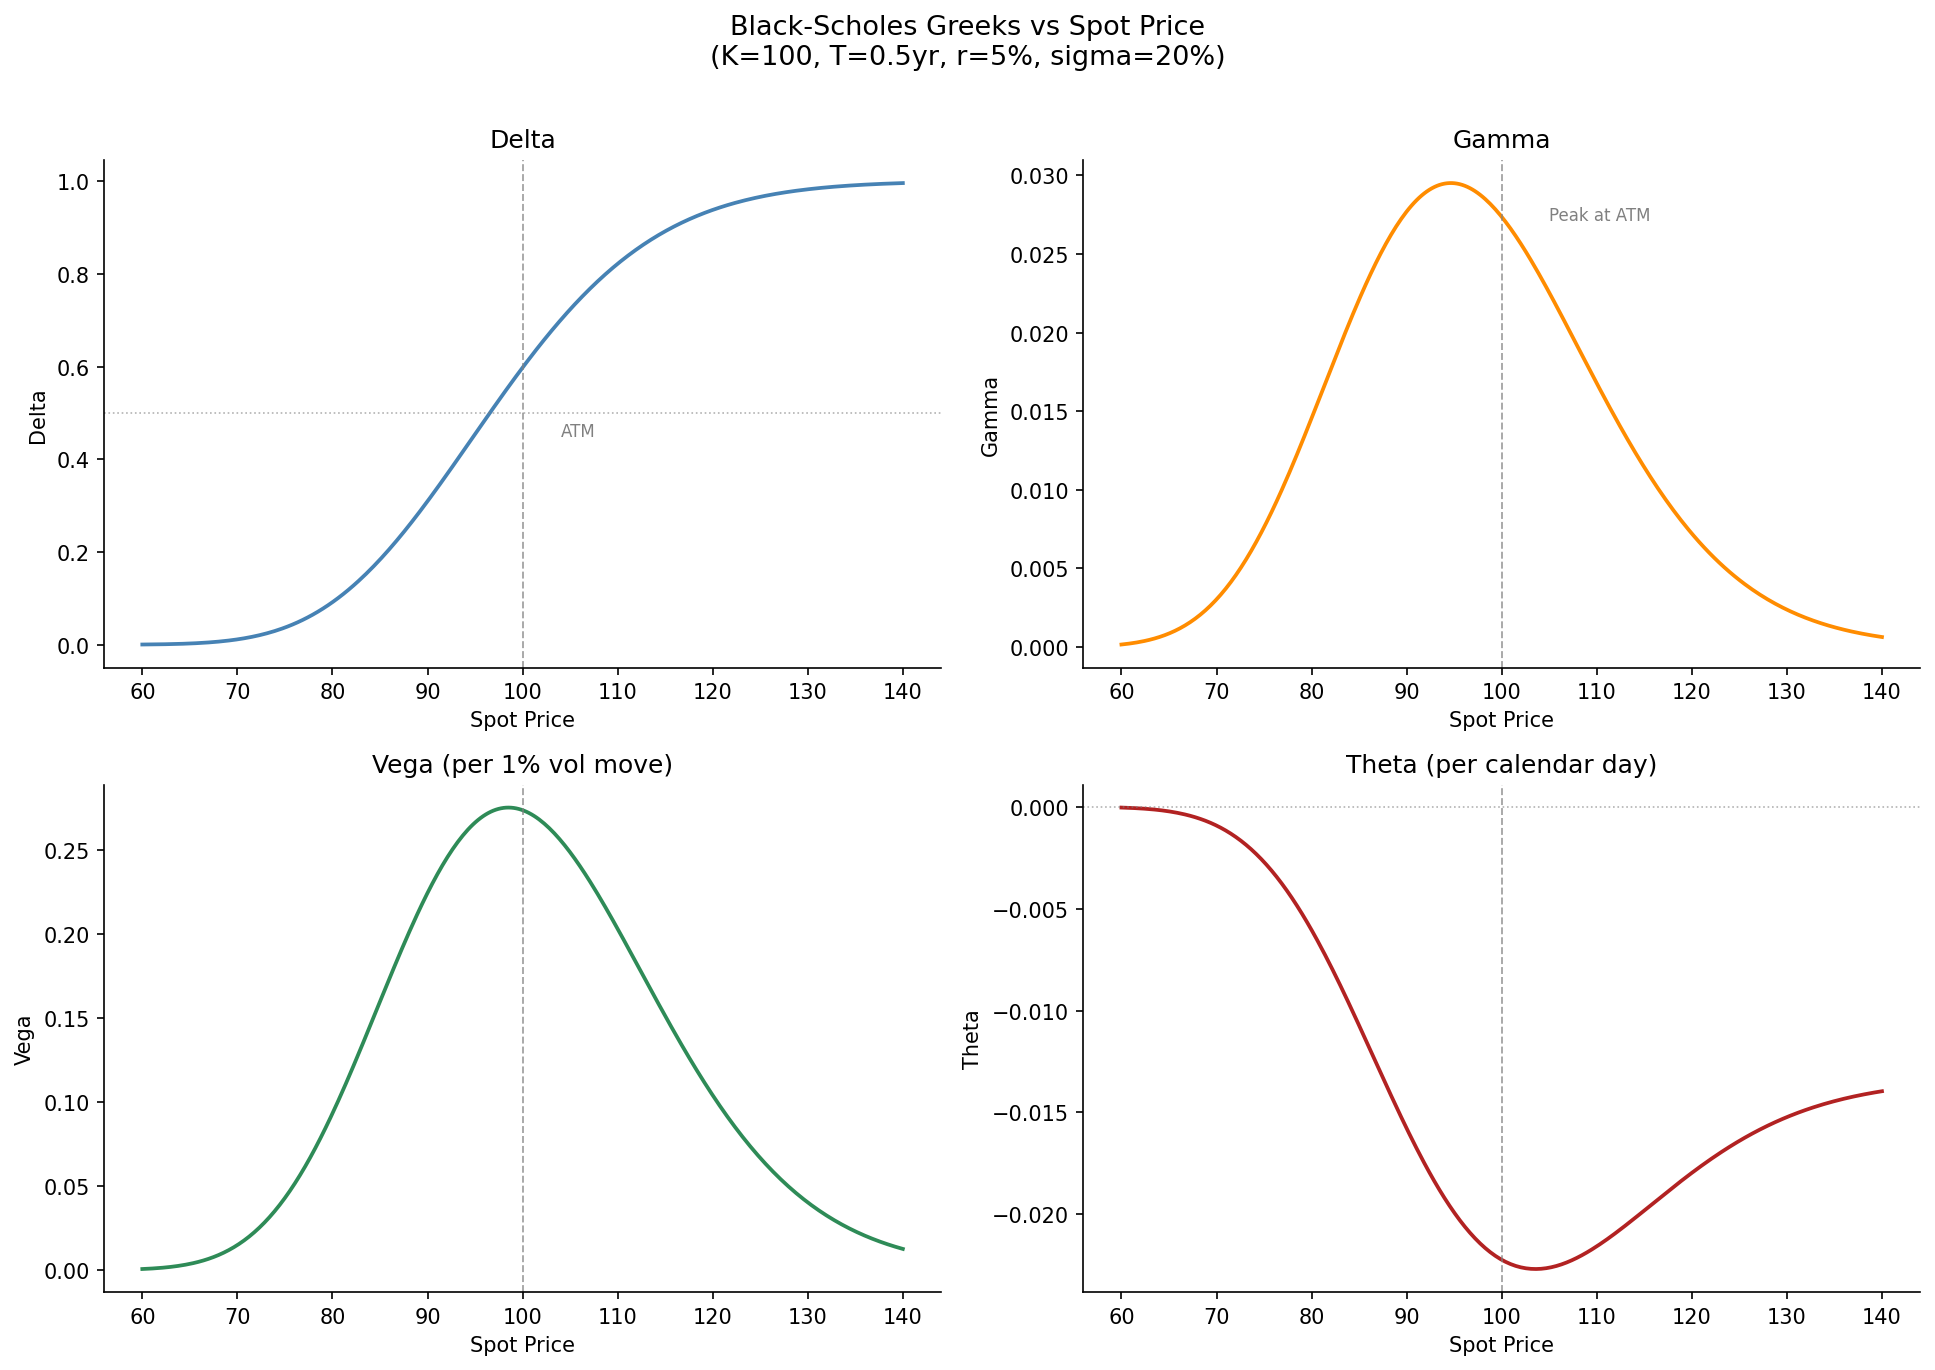

In [6]:
# Step 3 - Plot all four Greeks across a range of spot prices
# Strike fixed at 100, T=0.5yr, r=5%, sigma=20%
# Spot range chosen to show ITM, ATM, and OTM regions clearly

K_plot     = 100
T_plot     = 0.5
r_plot     = 0.05
sigma_plot = 0.20
spot_range = np.linspace(60, 140, 300)

greeks_list = [bs_greeks(S, K_plot, T_plot, r_plot, sigma_plot) for S in spot_range]

deltas = [g['delta'] for g in greeks_list]
gammas = [g['gamma'] for g in greeks_list]
vegas  = [g['vega']  for g in greeks_list]
thetas = [g['theta'] for g in greeks_list]

fig, axes = plt.subplots(2, 2, figsize=(13, 9))
fig.suptitle('Black-Scholes Greeks vs Spot Price\n(K=100, T=0.5yr, r=5%, sigma=20%)',
             fontsize=13, y=1.01)

# Delta
axes[0, 0].plot(spot_range, deltas, color='steelblue', linewidth=1.8)
axes[0, 0].axvline(K_plot, color='gray', linestyle='--', linewidth=0.9, alpha=0.7)
axes[0, 0].axhline(0.5, color='gray', linestyle=':', linewidth=0.8, alpha=0.6)
axes[0, 0].set_title('Delta')
axes[0, 0].set_ylabel('Delta')
axes[0, 0].set_xlabel('Spot Price')
axes[0, 0].annotate('ATM', xy=(100, 0.5), xytext=(104, 0.45), fontsize=8, color='gray')

# Gamma
axes[0, 1].plot(spot_range, gammas, color='darkorange', linewidth=1.8)
axes[0, 1].axvline(K_plot, color='gray', linestyle='--', linewidth=0.9, alpha=0.7)
axes[0, 1].set_title('Gamma')
axes[0, 1].set_ylabel('Gamma')
axes[0, 1].set_xlabel('Spot Price')
axes[0, 1].annotate('Peak at ATM', xy=(100, max(gammas)),
                    xytext=(105, max(gammas)*0.92), fontsize=8, color='gray')

# Vega
axes[1, 0].plot(spot_range, vegas, color='seagreen', linewidth=1.8)
axes[1, 0].axvline(K_plot, color='gray', linestyle='--', linewidth=0.9, alpha=0.7)
axes[1, 0].set_title('Vega (per 1% vol move)')
axes[1, 0].set_ylabel('Vega')
axes[1, 0].set_xlabel('Spot Price')

# Theta
axes[1, 1].plot(spot_range, thetas, color='firebrick', linewidth=1.8)
axes[1, 1].axvline(K_plot, color='gray', linestyle='--', linewidth=0.9, alpha=0.7)
axes[1, 1].axhline(0, color='gray', linestyle=':', linewidth=0.8, alpha=0.6)
axes[1, 1].set_title('Theta (per calendar day)')
axes[1, 1].set_ylabel('Theta')
axes[1, 1].set_xlabel('Spot Price')

plt.tight_layout()
savefig('greeks_vs_spot.png')
plt.show()

Greeks peak at ATM because uncertainty about expiry outcome is maximised when spot
equals strike. Delta-hedging is most expensive to maintain near ATM (high Gamma),
and time decay is fastest there (most negative Theta). The Gamma-Theta relationship
is central to options market-making: long Gamma positions earn from large moves but
pay daily Theta; short Gamma positions collect Theta but are exposed to large moves.

In [7]:
# Step 4 - CRR binomial tree pricer for European call
# u and d are calibrated to match Black-Scholes volatility exactly
# Backward induction from terminal payoffs to present value

def binomial_tree_call(S, K, T, r, sigma, N):
    """
    European call price via CRR binomial tree.

    S     : spot price
    K     : strike price
    T     : time to expiry in years
    r     : continuously compounded risk-free rate
    sigma : annualised volatility
    N     : number of time steps

    Returns option price (float)
    """
    dt = T / N
    u  = np.exp(sigma * np.sqrt(dt))
    d  = 1 / u
    p  = (np.exp(r * dt) - d) / (u - d)

    # terminal stock prices at expiry
    j        = np.arange(N + 1)
    ST       = S * u**(N - j) * d**j

    # terminal option payoffs
    payoffs  = np.maximum(ST - K, 0)

    # backward induction: discount one step at a time
    for _ in range(N):
        payoffs = np.exp(-r * dt) * (p * payoffs[:-1] + (1 - p) * payoffs[1:])

    return payoffs[0]


print("Binomial tree function loaded.")

Binomial tree function loaded.


In [8]:
# Step 4 - Validate binomial tree against Black-Scholes at N=500
# At high N the two prices should agree to within ~0.001

bs_price = bs_call(S_test, K_test, T_test, r_test, sigma_test)[0]
bt_price = binomial_tree_call(S_test, K_test, T_test, r_test, sigma_test, N=500)

print(f"Black-Scholes price : {bs_price:.4f}")
print(f"Binomial tree N=500 : {bt_price:.4f}")
print(f"Difference          : {abs(bs_price - bt_price):.6f}")

Black-Scholes price : 10.4506
Binomial tree N=500 : 10.4466
Difference          : 0.003998


Saved: binomial_convergence.png


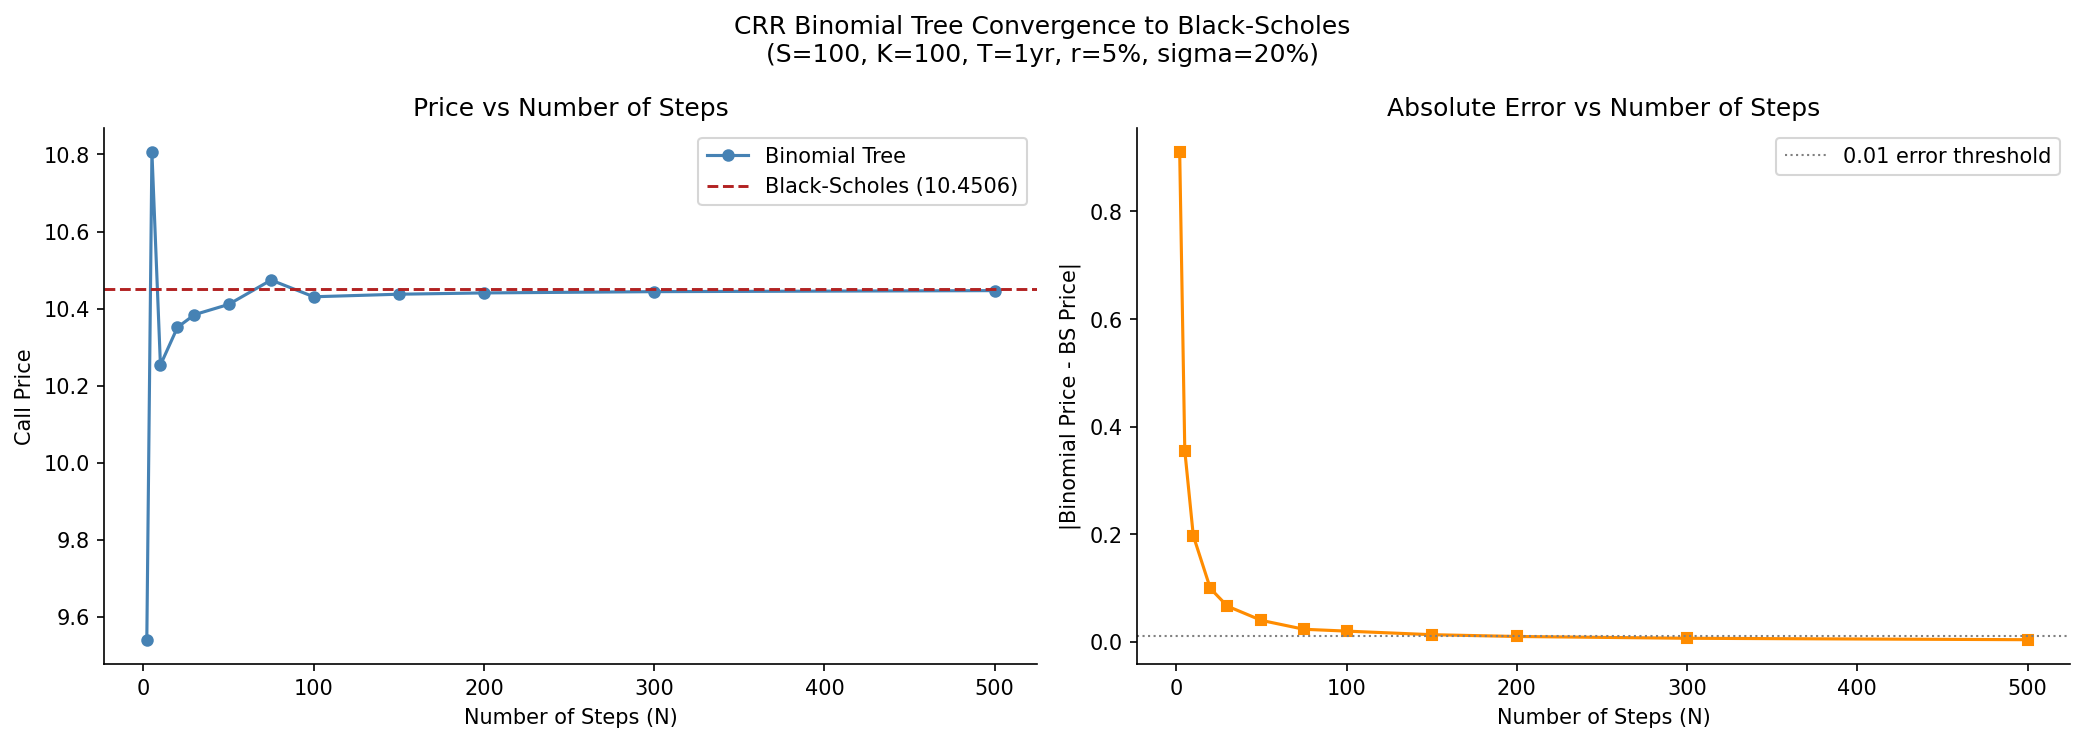

  N  BT Price  BS Price  Error
  2    9.5405   10.4506 0.9101
  5   10.8059   10.4506 0.3554
 10   10.2534   10.4506 0.1972
 20   10.3513   10.4506 0.0993
 30   10.3842   10.4506 0.0664
 50   10.4107   10.4506 0.0399
 75   10.4740   10.4506 0.0234
100   10.4306   10.4506 0.0200
150   10.4373   10.4506 0.0133
200   10.4406   10.4506 0.0100
300   10.4439   10.4506 0.0067
500   10.4466   10.4506 0.0040


In [9]:
# Step 5 - Binomial tree convergence to Black-Scholes price
# Steps chosen to show early oscillation and eventual dampening
# BS price shown as flat reference line

bs_price = bs_call(S_test, K_test, T_test, r_test, sigma_test)[0]

steps    = [2, 5, 10, 20, 30, 50, 75, 100, 150, 200, 300, 500]
bt_prices = [binomial_tree_call(S_test, K_test, T_test, r_test, sigma_test, N)
             for N in steps]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('CRR Binomial Tree Convergence to Black-Scholes\n'
             '(S=100, K=100, T=1yr, r=5%, sigma=20%)', fontsize=12)

# left panel: price convergence
axes[0].plot(steps, bt_prices, 'o-', color='steelblue', linewidth=1.5,
             markersize=5, label='Binomial Tree')
axes[0].axhline(y=bs_price, color='firebrick', linestyle='--', linewidth=1.4,
                label=f'Black-Scholes ({bs_price:.4f})')
axes[0].set_xlabel('Number of Steps (N)')
axes[0].set_ylabel('Call Price')
axes[0].set_title('Price vs Number of Steps')
axes[0].legend()

# right panel: absolute error
errors = [abs(p - bs_price) for p in bt_prices]
axes[1].plot(steps, errors, 's-', color='darkorange', linewidth=1.5, markersize=5)
axes[1].axhline(y=0.01, color='gray', linestyle=':', linewidth=1.0,
                label='0.01 error threshold')
axes[1].set_xlabel('Number of Steps (N)')
axes[1].set_ylabel('|Binomial Price - BS Price|')
axes[1].set_title('Absolute Error vs Number of Steps')
axes[1].legend()

plt.tight_layout()
savefig('binomial_convergence.png')
plt.show()

# print the convergence table
conv_df = pd.DataFrame({'N': steps, 'BT Price': bt_prices,
                        'BS Price': bs_price,
                        'Error': errors})
print(conv_df.to_string(index=False))

The CRR binomial tree converges to the Black-Scholes price as N increases,
confirming that the two models share the same theoretical foundation. At low
step counts (N=2 to N=30) the tree oscillates around the BS price due to the
coarseness of the discrete approximation. Error falls below 0.01 at N=200 and
reaches 0.004 at N=500. In practice N=100 is sufficient, giving error well
within typical bid-ask spreads. The residual error at high N is a known CRR
artifact caused by even/odd step alternation, not a formula error.

In [10]:
# inspecting raw file structure to determine correct skiprows and column layout

with open('../data/nifty_option_chain.csv', 'r') as f:
    for i, line in enumerate(f):
        print(f"Line {i}: {line[:120]}")
        if i >= 6:
            break

Line 0: CALLS,,PUTS

Line 1: ,OI,CHNG IN OI,VOLUME,IV,LTP,CHNG,BID QTY,BID,ASK,ASK QTY,STRIKE,BID QTY,BID,ASK,ASK QTY,CHNG,LTP,IV,VOLUME,CHNG IN OI,O
Line 2: ,8,-,-,74.83,-,-,780,"3,439.90","3,546.50","1,430","20,100.00","4,745",2.30,2.35,"1,495",0.05,2.30,42.89,"5,075",999,"10
Line 3: ,1,-,-,-,-,-,780,"3,075.30","3,475.65",65,"20,150.00",325,2.50,2.65,"4,420",0.10,2.75,43.15,149,59,260,

Line 4: ,1,-,-,-,-,-,780,"3,334.15","3,425.70",780,"20,200.00","1,300",2.55,2.60,910,0.05,2.60,42.19,"1,020",177,"1,536",

Line 5: ,1,-,-,-,-,-,780,"2,983.40","3,375.70",65,"20,250.00","1,430",2.65,2.80,130,0.50,2.85,41.96,214,77,176,

Line 6: ,2,-,-,-,-,-,65,"3,246.30","3,325.35",65,"20,300.00",650,2.70,2.75,195,0.10,2.80,41.44,"1,724",348,686,



In [11]:
# Step 6 - Parse NSE options chain CSV
# Row 0 is CALLS/PUTS label, Row 1 is column headers, data from Row 2
# Strike is at column index 11, calls on left, puts on right
# Commas inside quoted numbers need to be handled with thousands separator

S_spot  = 23599.90
T_exp   = 8 / 365
r_exp   = 0.0625   # RBI repo rate as of May 2026, used as risk-free rate approximation

cols = [
    'blank', 'c_oi', 'c_chng_oi', 'c_volume', 'c_iv', 'c_ltp', 'c_chng',
    'c_bid_qty', 'c_bid', 'c_ask', 'c_ask_qty',
    'strike',
    'p_bid_qty', 'p_bid', 'p_ask', 'p_ask_qty', 'p_chng', 'p_ltp', 'p_iv',
    'p_volume', 'p_chng_oi', 'p_oi', 'trailing'
]

raw = pd.read_csv(
    '../data/nifty_option_chain.csv',
    skiprows=1,
    header=0,
    names=cols,
    thousands=',',
    on_bad_lines='skip'
)

# drop blank and trailing columns
raw = raw.drop(columns=['blank', 'trailing'], errors='ignore')

# keep only strike, call LTP, put LTP, call IV, put IV
chain = raw[['strike', 'c_ltp', 'c_iv', 'p_ltp', 'p_iv']].copy()

# convert to numeric, coerce anything non-numeric to NaN
for col in chain.columns:
    chain[col] = pd.to_numeric(chain[col], errors='coerce')

# drop rows where strike is missing
chain = chain.dropna(subset=['strike'])

# keep strikes within a reasonable range around spot
chain = chain[(chain['strike'] >= S_spot * 0.85) &
              (chain['strike'] <= S_spot * 1.15)]

chain = chain.reset_index(drop=True)

print(f"Spot          : {S_spot}")
print(f"Expiry        : 26-May-2026  (T = {T_exp:.4f} years)")
print(f"Risk-free rate: {r_exp:.4f} (RBI repo rate)")
print(f"Strikes loaded: {len(chain)}")
print(f"Strike range  : {chain['strike'].min():.0f} to {chain['strike'].max():.0f}")
print()
print(chain.head(10).to_string(index=False))

Spot          : 23599.9
Expiry        : 26-May-2026  (T = 0.0219 years)
Risk-free rate: 0.0625 (RBI repo rate)
Strikes loaded: 141
Strike range  : 20100 to 27100

    strike  c_ltp    c_iv  p_ltp    p_iv
20100.0000    NaN 74.8300 2.3000 42.8900
20150.0000    NaN     NaN 2.7500 43.1500
20200.0000    NaN     NaN 2.6000 42.1900
20250.0000    NaN     NaN 2.8500 41.9600
20300.0000    NaN     NaN 2.8000 41.4400
20350.0000    NaN     NaN 2.8000 40.8500
20400.0000    NaN     NaN 2.9000 40.4100
20450.0000    NaN     NaN 3.0000 39.9800
20500.0000    NaN     NaN 3.1500 39.5300
20550.0000    NaN     NaN 3.0000 38.7800


In [12]:
# Step 7 - Extract implied volatility from market prices using Brent's method
# Use call prices for strikes >= spot, put prices for strikes < spot
# NSE's own IV column used as sanity check after computation

from scipy.optimize import brentq

def implied_vol_call(market_price, S, K, T, r):
    """Extract IV from call price using Brent's root finding."""
    intrinsic = max(S - K * np.exp(-r * T), 0)
    if market_price <= intrinsic or market_price <= 0:
        return np.nan
    def objective(sigma):
        return bs_call(S, K, T, r, sigma)[0] - market_price
    try:
        return brentq(objective, 1e-6, 10.0, xtol=1e-6, maxiter=500)
    except (ValueError, RuntimeError):
        return np.nan


def implied_vol_put(market_price, S, K, T, r):
    """Extract IV from put price using Brent's root finding."""
    intrinsic = max(K * np.exp(-r * T) - S, 0)
    if market_price <= intrinsic or market_price <= 0:
        return np.nan
    def objective(sigma):
        return bs_put(S, K, T, r, sigma)[0] - market_price
    try:
        return brentq(objective, 1e-6, 10.0, xtol=1e-6, maxiter=500)
    except (ValueError, RuntimeError):
        return np.nan


# apply: calls for strikes at or above spot, puts for strikes below spot
iv_results = []

for _, row in chain.iterrows():
    K    = row['strike']
    c_ltp = row['c_ltp']
    p_ltp = row['p_ltp']

    if K >= S_spot and not np.isnan(c_ltp):
        iv = implied_vol_call(c_ltp, S_spot, K, T_exp, r_exp)
        side = 'call'
        nse_iv = row['c_iv']
    elif K < S_spot and not np.isnan(p_ltp):
        iv = implied_vol_put(p_ltp, S_spot, K, T_exp, r_exp)
        side = 'put'
        nse_iv = row['p_iv']
    else:
        continue

    iv_results.append({
        'strike'  : K,
        'side'    : side,
        'ltp'     : c_ltp if side == 'call' else p_ltp,
        'iv_calc' : round(iv * 100, 2) if not np.isnan(iv) else np.nan,
        'iv_nse'  : nse_iv
    })

iv_df = pd.DataFrame(iv_results).dropna(subset=['iv_calc'])
iv_df = iv_df[(iv_df['iv_calc'] > 5) & (iv_df['iv_calc'] < 200)]
iv_df = iv_df.reset_index(drop=True)

print(f"Strikes with valid IV : {len(iv_df)}")
print(f"IV range              : {iv_df['iv_calc'].min():.1f}% to {iv_df['iv_calc'].max():.1f}%")
print()
print(iv_df.to_string(index=False))

Strikes with valid IV : 141
IV range              : 17.0% to 43.0%

    strike side      ltp  iv_calc  iv_nse
20100.0000  put   2.3000  42.7400 42.8900
20150.0000  put   2.7500  43.0100 43.1500
20200.0000  put   2.6000  42.1400 42.1900
20250.0000  put   2.8500  41.9900 41.9600
20300.0000  put   2.8000  41.3000 41.4400
20350.0000  put   2.8000  40.7000 40.8500
20400.0000  put   2.9000  40.2700 40.4100
20450.0000  put   3.0000  39.8300 39.9800
20500.0000  put   3.1500  39.4600 39.5300
20550.0000  put   3.0000  38.6300 38.7800
20600.0000  put   3.3000  38.4700 38.6200
20650.0000  put   3.2500  37.8000 37.9400
20700.0000  put   3.3500  37.3300 37.4800
20750.0000  put   3.1500  36.4600 36.6000
20800.0000  put   3.6000  36.4500 36.6000
20850.0000  put   2.9000  34.9100 35.0500
20900.0000  put   3.8000  35.4800 35.6300
20950.0000  put   4.0500  35.1500 35.3000
21000.0000  put   4.2000  34.7000 34.8000
21050.0000  put   4.1500  34.0300 34.1900
21100.0000  put   4.3000  33.5800 33.6800
21150.00

Saved: iv_smile.png


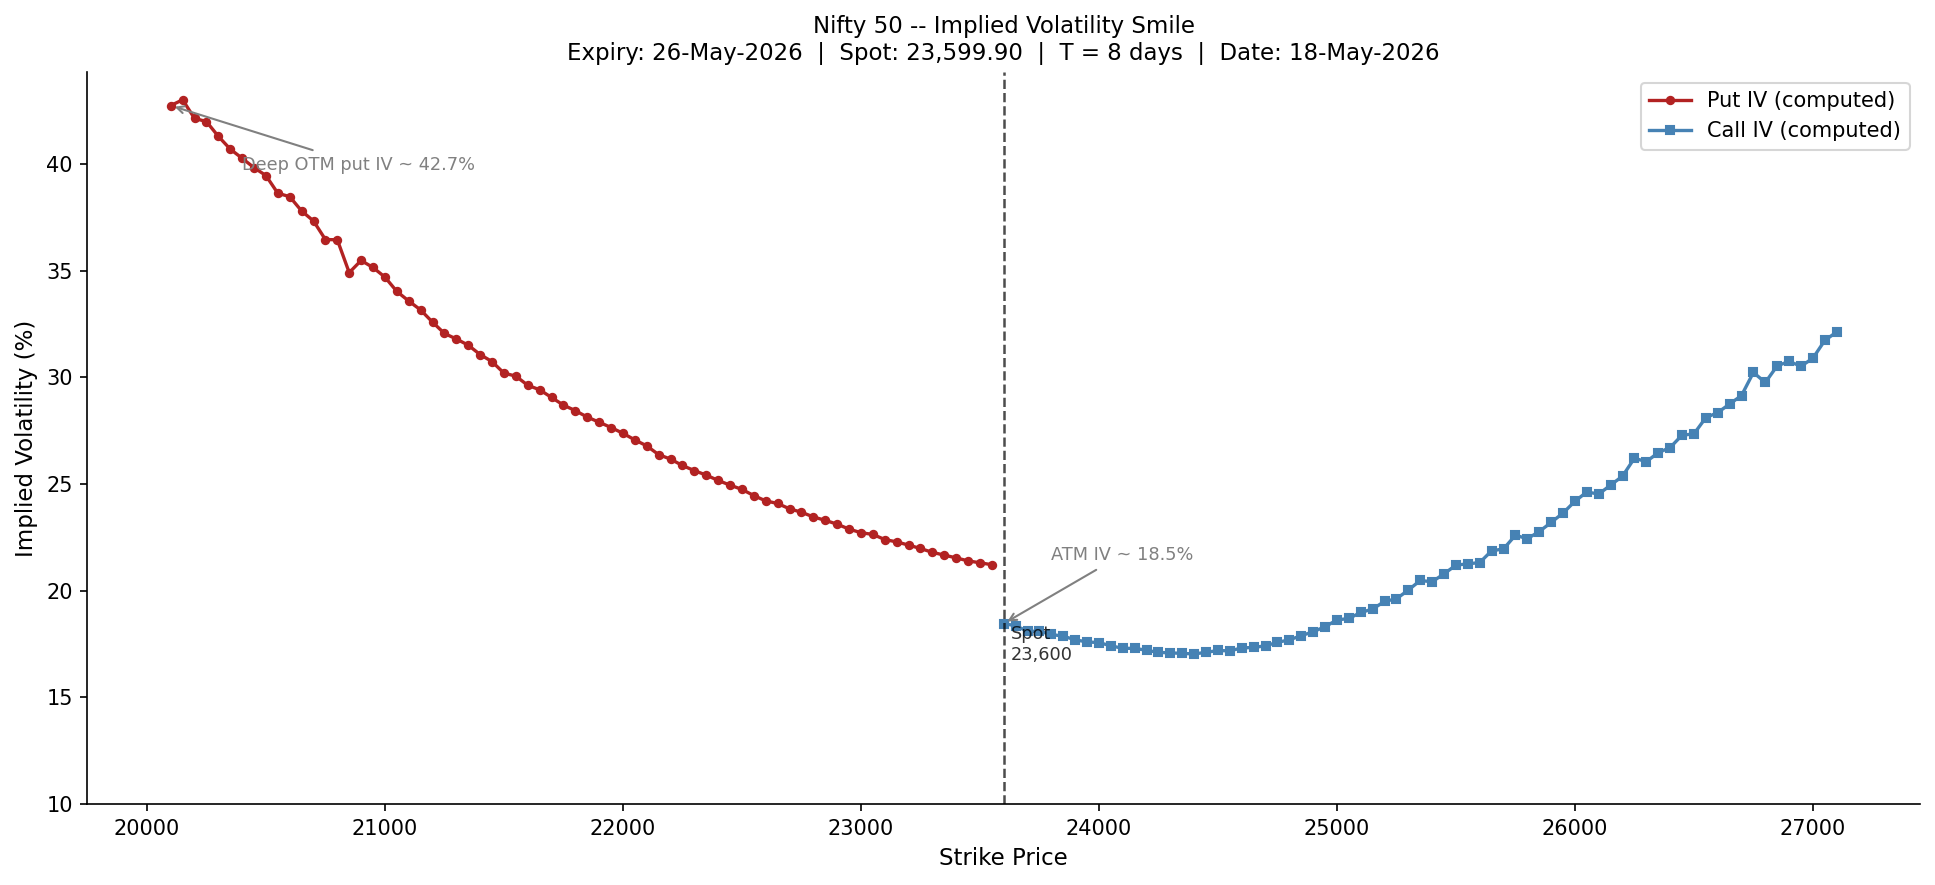

ATM IV (nearest strike)  : 18.46%
Min IV (call side)       : 17.04%  at strike 24400
Max IV (put side)        : 43.01%  at strike 20150
Skew (25-delta put - call IV approx) : 8.55pp


In [13]:
# Step 8 - Plot implied volatility smile from NSE Nifty 50 options chain
# Calls plotted in blue, puts in red, spot marked as vertical line
# Moneyness labels added to show ITM/ATM/OTM regions

calls_iv = iv_df[iv_df['side'] == 'call'].copy()
puts_iv  = iv_df[iv_df['side'] == 'put'].copy()

fig, ax = plt.subplots(figsize=(13, 6))

ax.plot(puts_iv['strike'], puts_iv['iv_calc'],
        'o-', color='firebrick', linewidth=1.6, markersize=3.5,
        label='Put IV (computed)')
ax.plot(calls_iv['strike'], calls_iv['iv_calc'],
        's-', color='steelblue', linewidth=1.6, markersize=3.5,
        label='Call IV (computed)')

# spot price line
ax.axvline(S_spot, color='black', linestyle='--', linewidth=1.2, alpha=0.7)
ax.text(S_spot + 30, ax.get_ylim()[0] + 1, f'Spot\n{S_spot:,.0f}',
        fontsize=8.5, color='black', alpha=0.8)

# ATM IV annotation
atm_row = iv_df.iloc[(iv_df['strike'] - S_spot).abs().argsort()[:1]]
atm_iv  = atm_row['iv_calc'].values[0]
atm_k   = atm_row['strike'].values[0]
ax.annotate(f'ATM IV ~ {atm_iv:.1f}%',
            xy=(atm_k, atm_iv),
            xytext=(atm_k + 200, atm_iv + 3),
            fontsize=8.5,
            arrowprops=dict(arrowstyle='->', color='gray', lw=1.0),
            color='gray')

# deep OTM put annotation
deep_put = puts_iv[puts_iv['strike'] == puts_iv['strike'].min()].iloc[0]
ax.annotate(f"Deep OTM put IV ~ {deep_put['iv_calc']:.1f}%",
            xy=(deep_put['strike'], deep_put['iv_calc']),
            xytext=(deep_put['strike'] + 300, deep_put['iv_calc'] - 3),
            fontsize=8.5,
            arrowprops=dict(arrowstyle='->', color='gray', lw=1.0),
            color='gray')

ax.set_xlabel('Strike Price', fontsize=11)
ax.set_ylabel('Implied Volatility (%)', fontsize=11)
ax.set_title('Nifty 50 -- Implied Volatility Smile\n'
             f'Expiry: 26-May-2026  |  Spot: {S_spot:,.2f}  |  '
             f'T = {T_exp*365:.0f} days  |  Date: 18-May-2026',
             fontsize=11)
ax.legend(fontsize=10)
ax.set_ylim(bottom=10)

plt.tight_layout()
savefig('iv_smile.png')
plt.show()

# summary statistics
print(f"ATM IV (nearest strike)  : {atm_iv:.2f}%")
print(f"Min IV (call side)       : {calls_iv['iv_calc'].min():.2f}%  "
      f"at strike {calls_iv.loc[calls_iv['iv_calc'].idxmin(), 'strike']:.0f}")
print(f"Max IV (put side)        : {puts_iv['iv_calc'].max():.2f}%  "
      f"at strike {puts_iv.loc[puts_iv['iv_calc'].idxmax(), 'strike']:.0f}")
print(f"Skew (25-delta put - call IV approx) : "
      f"{puts_iv[puts_iv['strike'] <= S_spot * 0.97]['iv_calc'].mean() - calls_iv[calls_iv['strike'] >= S_spot * 1.03]['iv_calc'].mean():.2f}pp")

The Nifty 50 implied volatility surface (26-May-2026 expiry, 8 days to expiry)
shows a pronounced negative skew. ATM IV is 18.5%, while deep OTM put IV reaches
43% at strike 20150 -- a 25pp premium over ATM. OTM call IV rises more gradually
to 32% at strike 27100. The skew spread (OTM put IV minus equidistant OTM call IV)
is approximately 8.55pp.

Under Black-Scholes, IV would be flat across all strikes -- a horizontal line at
the ATM level. The observed skew is direct evidence that the lognormal distribution
assumed by BS underestimates the probability of large downside moves. Traders price
OTM puts at a premium because institutional investors use them as portfolio insurance,
creating excess demand on the downside. This is the volatility risk premium embedded
in index options. The short expiry (8 days) amplifies the skew because near-term
event risk (macro data, RBI policy, global cues) is priced more acutely in short-
dated options than in longer-dated ones.